<a href="https://colab.research.google.com/github/idanm-commiting/Sanitation-Project/blob/main/B03_Chicago_Food_Inspection_Factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examining Factors Associated with Food Inspection Results in Chicago
**BA780 | Cohort B, Team 03 | Team Assignment**  
**Submission file:** `B03-Chicago-Food-Inspection-Factors.ipynb`  
**Data:** Chicago Department of Public Health Food Inspections and Chicago 311 sanitation complaints.  
**Access:** Five ZIP archives from the [team repository](https://github.com/idanm-commiting/Sanitation-Project), each containing CSV data. Download the files listed in the setup cell into a `data` folder beside this notebook. No credentials are required for the public repository.

## Executive summary
This report examines Chicago food-inspection outcomes and sanitation complaint patterns to guide inspection planning and compliance outreach.
We audited 315,488 inspection records and 266,702 complaints, removed duplicate records, standardized dates and ZIP codes, and separated outcome-bearing inspections from administrative statuses.
Among 103,614 eligible inspections in 2019–2025, 23.01% failed; High-risk and Low-risk inspections had failure rates of 22.92% and 25.89%, respectively.
The ten highest-volume ZIP codes account for 36.25% of retained 2011–2025 complaints, and long term care has the highest failure rate among the ten most-inspected facility categories.
We recommend reviewing outreach needs in the identified facility groups and validating common violation-code descriptions, while treating complaint counts as contextual workload measures rather than population-adjusted risk.
The final project phase should verify source coverage, add exposure denominators, and test ZIP/year associations while accounting for inspection mix; this descriptive phase does not establish causation.

## 1. Business problem and scope
Food and business operators need to identify where prevention and compliance support could be most useful. We examine how recorded failure rates differ by establishment risk and facility type, which violations are common among failed inspections, and where sanitation complaints are concentrated. We have included five interpretable charts,and a short list of evidence-based follow-up priorities. Inspection records include restaurants and other food establishments, so the results are not restaurant only.

Complaints and inspections remain separate observational units; this notebook does not claim that a complaint caused an inspection failure.


## 2. Reproducibility and data access
Run from the notebook's directory with Python, pandas 2.0+, NumPy, Matplotlib, and contextily installed. Use Restart Kernel and Run All; every code cell displays a result, and no network connection is needed once the archives and cached basemap are present. The input CSVs are preserved. Four inspection parts are concatenated; complaint records are kept separately rather than stacked into the same analytical table. The original cleaning notebook's audit is expanded below.

In [ ]:
from pathlib import Path
from zipfile import ZipFile
import sys
import hashlib
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11})
DATA_DIR = Path('data')
FOOD_FILES = ['Food_Inspections_part_1.zip', 'Food_Inspections_part_2a.zip',
              'Food_Inspections_part_2b.zip', 'Food_Inspections_part_3.zip']
COMPLAINT_FILE = '311_Sanitation_Combined_2010_2026.zip'
manifest = []
def load_archive(filename):
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'Download {filename} from the team repository into {DATA_DIR.resolve()}')
    frames = []
    with ZipFile(path) as archive:
        names = [n for n in archive.namelist() if n.lower().endswith('.csv') and not n.startswith('__MACOSX/')]
        if not names:
            raise ValueError(f'No CSV found in {filename}')
        for name in names:
            with archive.open(name) as file:
                frames.append(pd.read_csv(file, low_memory=False))
    frame = pd.concat(frames, ignore_index=True)
    frame.columns = frame.columns.str.strip()
    manifest.append({'File': filename, 'Rows': len(frame), 'Columns': len(frame.columns),
                     'SHA256': hashlib.sha256(path.read_bytes()).hexdigest()})
    return frame

food_raw = pd.concat([load_archive(f) for f in FOOD_FILES], ignore_index=True)
complaints_raw = load_archive(COMPLAINT_FILE)
print(f'Python {sys.version.split()[0]}; pandas {pd.__version__}; NumPy {np.__version__}; Matplotlib {matplotlib.__version__}')
display(pd.DataFrame(manifest))

Python 3.13.7; pandas 2.3.3; NumPy 2.3.3; Matplotlib 3.10.7


,File,Rows,Columns,SHA256
0,Food_Inspections_part_1.zip,105162,18,7997ac50fcf2acce89814c4c16dab34d33461810838c61...
1,Food_Inspections_part_2a.zip,52581,18,51109a6ee554a5f2fdec93c36112f22936d30cea349808...
2,Food_Inspections_part_2b.zip,52582,18,197d1421f351162228e8aa5a6f2348614773a104e64044...
3,Food_Inspections_part_3.zip,105163,18,1b590de50749567f823656ce47d260ff57c80251dedeed...
4,311_Sanitation_Combined_2010_2026.zip,266702,13,0fb60943c2cf5fbf837a51e52d72941c426b8bb26165fb...


### Data dictionary and provenance
| Field | Dataset / meaning | Analytical use |
|---|---|---|
| Inspection ID | Identifier for an inspection event, not a business | Deduplication |
| Inspection Date / Year | Event date / derived year | Coverage and time filters |
| Results | Pass, Pass w/ Conditions, Fail, and non-outcome statuses | Failure denominator |
| Risk | Recorded High, Medium, Low risk category | Group comparison |
| Facility Type | Establishment category | Group comparison |
| Violations | Pipe-separated inspector findings | Violation mentions, not causal predictors |
| Request Number | 311 service-request identifier | Complaint deduplication |
| Created Date / Closed Date | Complaint opening / closure dates | Trend / quality audit |
| ZIP Code / Zip | Postal area identifier | Complaint concentration; future linkage |
| Latitude / Longitude | Recorded coordinates | Quality flags; no row deletion solely for missing coordinates |

The supplied Chicago Word document described 152,664 historical complaints. The available combined extract is larger and extends beyond that historical series; therefore its approximate counts and draft findings are not reused. The combined file does not retain a source-system column, so its exact historical/modern stitching procedure must be confirmed with the team before final-phase linkage. Archive hashes identify this report's inputs; their download dates were not recorded.

**Takeaway:** Findings below describe the supplied snapshot, not the changing live portal or the smaller dataset in the draft report.

## 3. Cleaning and quality audit
### 3.1 Before cleaning
Check types, missingness, duplicate IDs, categories, and observed coverage before choosing exclusions. Missing violation text is not automatically evidence of zero violations.

In [ ]:
for label, frame, key in [('Food', food_raw, 'Inspection ID'), ('311', complaints_raw, 'Request Number')]:
    print(f'\n{label}: {len(frame):,} rows; {len(frame.columns)} columns')
    frame.info()
    display(pd.DataFrame({'Missing': frame.isna().sum(), 'Missing %': frame.isna().mean().mul(100).round(2)}).sort_values('Missing', ascending=False))
    print('Exact duplicate rows:', frame.duplicated().sum(), '| Repeated IDs:', frame[key].duplicated().sum())
display(food_raw['Results'].value_counts(dropna=False).rename('Inspections').to_frame())
display(complaints_raw['Status'].value_counts(dropna=False).rename('Requests').to_frame())


Food: 315,488 rows; 18 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315488 entries, 0 to 315487
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Inspection ID    315488 non-null  int64  
 1   DBA Name         315488 non-null  object 
 2   AKA Name         313065 non-null  object 
 3   License #        315469 non-null  float64
 4   Facility Type    310149 non-null  object 
 5   Risk             315401 non-null  object 
 6   Address          315488 non-null  object 
 7   City             315308 non-null  object 
 8   State            315413 non-null  object 
 9   Zip              315446 non-null  float64
 10  Inspection Date  315488 non-null  object 
 11  Inspection Type  315487 non-null  object 
 12  Results          315488 non-null  object 
 13  Violations       226565 non-null  object 
 14  Latitude         314443 non-null  float64
 15  Longitude        314443 non-null  float64
 16  Locati

,Missing,Missing %
Violations,88923,28.19
Facility Type,5339,1.69
AKA Name,2423,0.77
Longitude,1045,0.33
Latitude,1045,0.33
Location,1045,0.33
City,180,0.06
Risk,87,0.03
State,75,0.02
Zip,42,0.01


,Missing,Missing %
ZIP Code,14399,5.40
Closed Date,1083,0.41
Community Area,177,0.07
Ward,171,0.06
Police District,167,0.06
Longitude,157,0.06
Latitude,157,0.06
Street Address,126,0.05
Request Number,0,0.00
Request Type,0,0.00


,Inspections
Results,
Pass,163268
Fail,60762
Pass w/ Conditions,46817
Out of Business,25846
No Entry,14110
Not Ready,4590
Business Not Located,95


,Requests
Status,
Completed,258146
Completed - Dup,7212
Open,1023
Canceled,261
Open - Dup,60


**Takeaway:** Non-outcome inspection statuses and duplicate complaint records require separate handling; blanket deletion of incomplete rows would discard usable observations.

### 3.2 Cleaning decisions
| Issue | Action | Rationale |
|---|---|---|
| Exact duplicates / repeated identifiers | Remove exact duplicates, then retain the first nonmissing ID in source order; retain missing IDs and report them | Count each identified event once; source order is deterministic, not proof of the latest revision |
| Complaint statuses containing “Dup” | Remove before request-ID deduplication | Do not count marked duplicate requests as independent complaints |
| Dates and supplied Year | Parse dates; derive Year anew; retain unparseable dates outside date-based analyses | Avoid relying on possibly stale derived fields |
| ZIP codes | Strip decimal suffix; require five digits, reject 00000; retain unknowns | ZIP is an identifier; format validation does not certify Chicago membership |
| Inspection outcome | Keep Pass, Pass w/ Conditions, Fail for rate analysis | Exclude no-entry/closed-business statuses from the denominator; conditional passes are non-failures |
| Risk / facility labels | Map known risks; trim and lowercase facility labels; keep Unknown | Avoid dropping records solely for missing category labels; no speculative spelling merges |
| Coordinates | Flag outside an approximate Chicago window or missing | Audit outliers without deleting otherwise useful records; window is not a city boundary |
| Very high counts | Retain | Large complaint totals may be real; no arbitrary winsorization |
| Joins | None in this phase | Avoid a many-to-many merge that multiplies inspections and complaints |

All time charts use 2011–2025 to avoid the sparse 2010 complaint edge and incomplete 2026. Inspection group and violation comparisons use 2019–2025, a common recent window that avoids pooling older violation eras. These are analytical windows, not a claim that every year has complete reporting.

In [ ]:
audit = []
def log(dataset, step, before, after):
    audit.append({'Dataset': dataset, 'Step': step, 'Before': before, 'After': after, 'Removed': before-after})

def dedupe(frame, key, label):
    result = frame.drop_duplicates().copy()
    log(label, 'Exact duplicate rows', len(frame), len(result))
    repeated = result[key].notna() & result[key].duplicated()
    out = result.loc[~repeated].copy()
    log(label, 'Repeated nonmissing ID (keep first)', len(result), len(out))
    return out

food = dedupe(food_raw, 'Inspection ID', 'Food')
complaints = complaints_raw.drop_duplicates().copy()
log('311', 'Exact duplicate rows', len(complaints_raw), len(complaints))
duplicate_status = complaints['Status'].astype('string').str.contains('Dup', case=False, na=False)
before = len(complaints)
complaints = complaints.loc[~duplicate_status].copy()
log('311', 'Status marked duplicate', before, len(complaints))
complaints = dedupe(complaints, 'Request Number', '311')

def clean_zip(series):
    text = series.astype('string').str.strip().str.replace(r'\.0$', '', regex=True)
    return text.where(text.str.fullmatch(r'\d{5}', na=False) & text.ne('00000'))

for frame, date_col, zip_col in [(food, 'Inspection Date', 'Zip'), (complaints, 'Created Date', 'ZIP Code')]:
    frame[date_col] = pd.to_datetime(frame[date_col], format='mixed', errors='coerce')
    frame['Year'] = frame[date_col].dt.year.astype('Int64')
    frame['ZIP Clean'] = clean_zip(frame[zip_col])
    lat = pd.to_numeric(frame['Latitude'], errors='coerce')
    lon = pd.to_numeric(frame['Longitude'], errors='coerce')
    frame['Coordinate usable'] = lat.between(41.64, 42.03) & lon.between(-87.95, -87.50)

complaints['Closed Date'] = pd.to_datetime(complaints['Closed Date'], format='mixed', errors='coerce')
food['Results'] = food['Results'].astype('string').str.strip()
food['Risk Clean'] = food['Risk'].astype('string').str.strip().map({'Risk 1 (High)': 'High', 'Risk 2 (Medium)': 'Medium', 'Risk 3 (Low)': 'Low'}).fillna('Unknown')
food['Facility Clean'] = food['Facility Type'].astype('string').str.strip().str.lower().replace('', pd.NA).fillna('unknown')
outcomes = food.loc[food['Results'].isin(['Pass', 'Pass w/ Conditions', 'Fail'])].copy()
outcomes['Failed'] = outcomes['Results'].eq('Fail').astype(int)
log('Food', 'Keep outcome-bearing inspections', len(food), len(outcomes))
analysis = outcomes.loc[outcomes['Year'].between(2019, 2025)].copy()
log('Food', 'Analysis window 2019–2025', len(outcomes), len(analysis))
complaint_analysis = complaints.loc[complaints['Year'].between(2011, 2025)].copy()
log('311', 'Analysis window 2011–2025', len(complaints), len(complaint_analysis))
display(pd.DataFrame(audit))

quality = []
for label, frame, date_col, key in [('Food cleaned', food, 'Inspection Date', 'Inspection ID'), ('311 cleaned', complaints, 'Created Date', 'Request Number')]:
    quality.append({'Dataset': label, 'Rows': len(frame), 'Earliest': str(frame[date_col].min().date()), 'Latest': str(frame[date_col].max().date()), 'Missing dates': int(frame[date_col].isna().sum()), 'Unknown ZIP': int(frame['ZIP Clean'].isna().sum()), 'Unusable coordinates': int((~frame['Coordinate usable']).sum()), 'Missing IDs': int(frame[key].isna().sum())})
display(pd.DataFrame(quality))
print('311 closure dates before creation:', int((complaints['Closed Date'] < complaints['Created Date']).sum()))
print('Analysis unknown risks:', int(analysis['Risk Clean'].eq('Unknown').sum()))
print('Analysis unknown facilities:', int(analysis['Facility Clean'].eq('unknown').sum()))
print('Analysis missing violation text:', int(analysis['Violations'].isna().sum()))
print('After-cleaning analysis types:')
analysis[['Inspection ID', 'Inspection Date', 'Year', 'ZIP Clean', 'Risk Clean', 'Facility Clean', 'Failed']].info()
complaint_analysis[['Request Number', 'Created Date', 'Year', 'ZIP Clean']].info()

311 closure dates before creation: 0
Analysis unknown risks: 2
Analysis unknown facilities: 116
Analysis missing violation text: 17254
After-cleaning analysis types:
<class 'pandas.core.frame.DataFrame'>
Index: 103614 entries, 11139 to 134811
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Inspection ID    103614 non-null  int64         
 1   Inspection Date  103614 non-null  datetime64[ns]
 2   Year             103614 non-null  Int64         
 3   ZIP Clean        103611 non-null  string        
 4   Risk Clean       103614 non-null  object        
 5   Facility Clean   103614 non-null  string        
 6   Failed           103614 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), int64(2), object(1), string(2)
memory usage: 6.4+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 245373 entries, 0 to 266701
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 

,Dataset,Step,Before,After,Removed
0,Food,Exact duplicate rows,315488,315488,0
1,Food,Repeated nonmissing ID (keep first),315488,315488,0
2,311,Exact duplicate rows,266702,266700,2
3,311,Status marked duplicate,266700,259428,7272
4,311,Exact duplicate rows,259428,259428,0
5,311,Repeated nonmissing ID (keep first),259428,258623,805
6,Food,Keep outcome-bearing inspections,315488,270847,44641
7,Food,Analysis window 2019–2025,270847,103614,167233
8,311,Analysis window 2011–2025,258623,245373,13250


,Dataset,Rows,Earliest,Latest,Missing dates,Unknown ZIP,Unusable coordinates,Missing IDs
0,Food cleaned,315488,2010-01-04,2026-09-14,0,42,1045,0
1,311 cleaned,258623,2010-11-19,2026-09-24,0,14410,157,0


**Takeaway:** Cleaning retains 315,488 distinct identified inspection records and 258,623 complaint records before analytical date restrictions. The rate comparisons use 103,614 outcome-bearing inspections in 2019–2025; exclusions and missing fields are reported above rather than hidden.

## 4. Exploratory questions and five visualizations
### Q1. How does reported sanitation complaint volume vary by year?
**Decision:** Determine whether a single multi-year complaint total masks time variation relevant to staffing or later linkage. Each count is a retained service request, not a confirmed violation.

Peak: 2016 (19,970); lowest: 2019 (12,260).


,Complaints
Year,
2011,17207
2012,18065
2013,17081
2014,17860
2015,18286
2016,19970
2017,18767
2018,17188
2019,12260


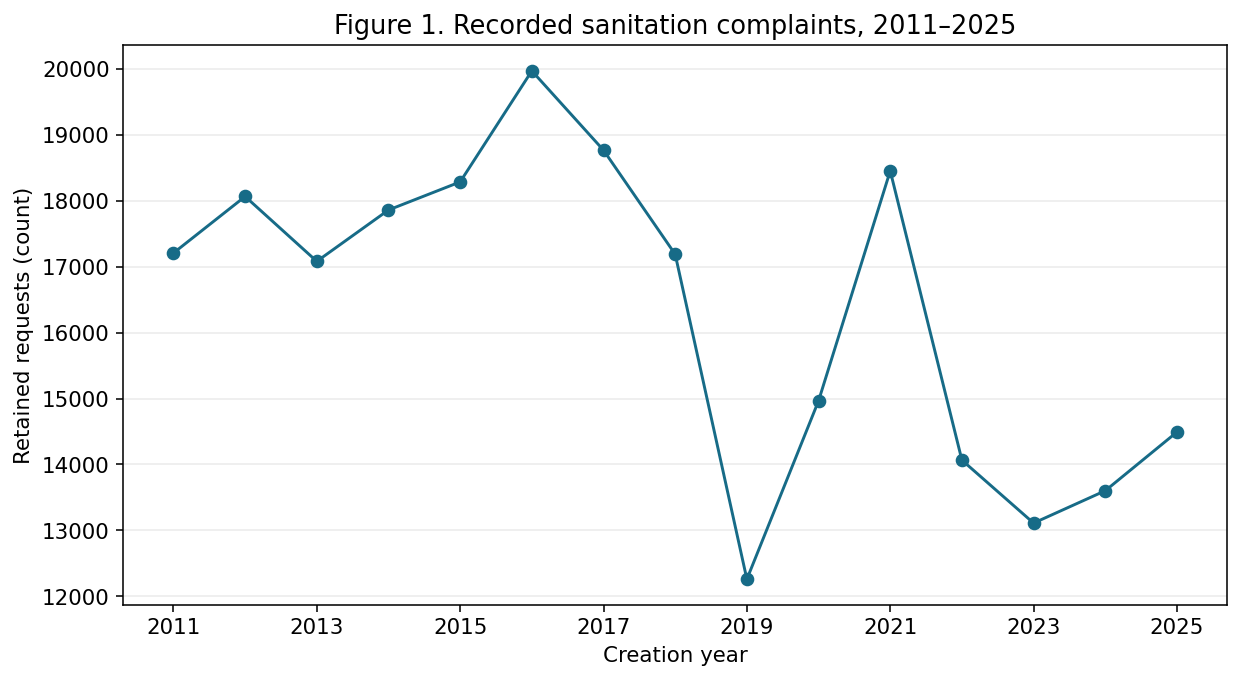

In [ ]:
annual = complaint_analysis.groupby('Year').size().reindex(range(2011, 2026), fill_value=0).rename('Complaints')
display(annual.to_frame())
fig, ax = plt.subplots()
ax.plot(annual.index, annual.values, marker='o', color='#176B87')
ax.set(title='Figure 1. Recorded sanitation complaints, 2011–2025', xlabel='Creation year', ylabel='Retained requests (count)')
ax.set_xticks(range(2011, 2026, 2))
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()
print(f'Peak: {annual.idxmax()} ({annual.max():,}); lowest: {annual.idxmin()} ({annual.min():,}).')

**Answer / takeaway:** The highest recorded volume is 19,970 requests in 2016, compared with 12,260 in 2019. Reporting access, extract coverage, and changes between source systems can affect these totals; a change in requests does not establish a change in underlying sanitation conditions. Validate yearly coverage before using this series to allocate resources.

### Q2. Which ZIP codes account for the largest share of reported complaints?
**Decision:** Identify locations for a closer review of neighborhood context. Use the same 2011–2025 window as Q1 and report how many requests lack a usable ZIP.

Top ten: 88,936 / 245,373 requests (36.25%).
Unknown or invalid ZIP: 11,476 (4.68%).


,Complaints
ZIP Clean,
60620,11282
60619,10875
60628,10576
60617,9418
60647,8854
60614,7950
60629,7618
60618,7541
60636,7490


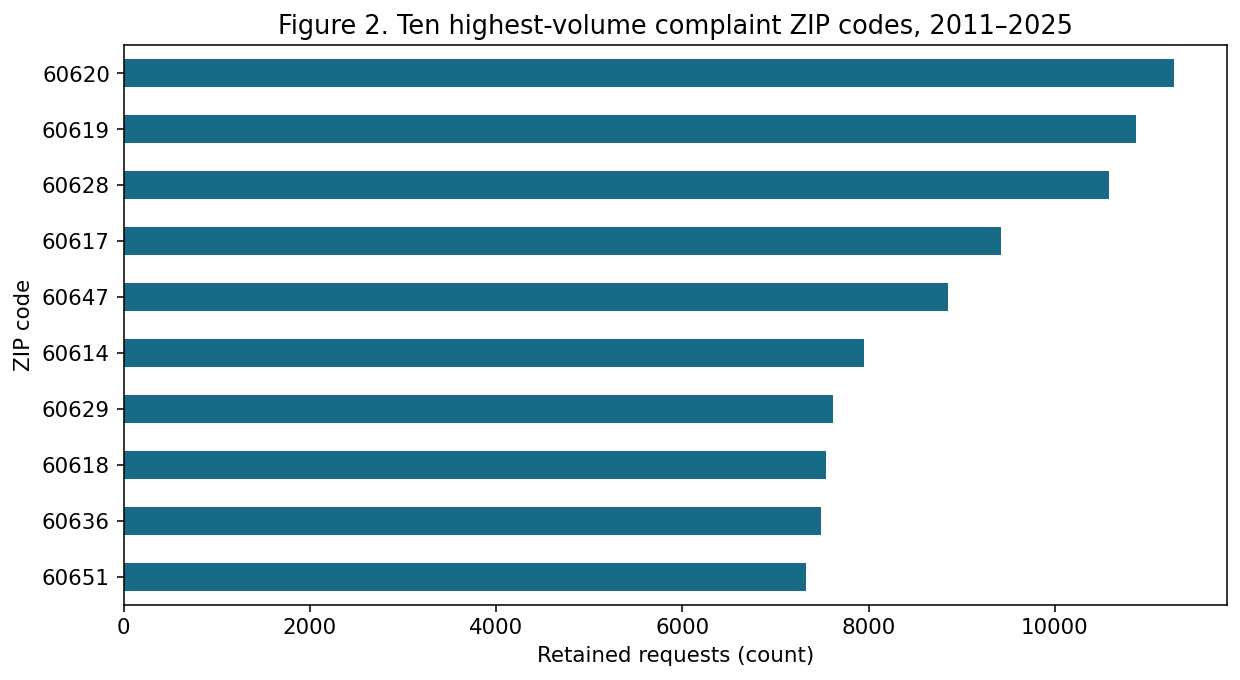

In [ ]:
zip_counts = complaint_analysis['ZIP Clean'].value_counts().head(10).rename('Complaints')
zip_share = zip_counts.sum() / len(complaint_analysis) * 100
missing_zip = complaint_analysis['ZIP Clean'].isna().sum()
display(zip_counts.to_frame())
fig, ax = plt.subplots()
zip_counts.sort_values().plot.barh(ax=ax, color='#176B87')
ax.set(title='Figure 2. Ten highest-volume complaint ZIP codes, 2011–2025', xlabel='Retained requests (count)', ylabel='ZIP code')
plt.tight_layout()
plt.show()
print(f'Top ten: {zip_counts.sum():,} / {len(complaint_analysis):,} requests ({zip_share:.2f}%).')
print(f'Unknown or invalid ZIP: {missing_zip:,} ({missing_zip/len(complaint_analysis):.2%}).')

**Answer / takeaway:** ZIP 60620 has the largest count (11,282); the top ten account for 36.25% of all retained requests in the window, including requests without ZIPs in that denominator. These are workload counts, not population-adjusted sanitation rates. Compare population, food-business counts, and missing-ZIP patterns before labeling any area as higher risk.

### Q3. Which community areas have the most recorded sanitation complaints?
**Decision:** Locate complaint workload using administrative areas as a complement to ZIP codes. Adapted from Jason's sanitation notebook, using the same deduplicated 2011–2025 requests as Figures 1–2. Valid IDs are whole numbers from 1 to 77; zero, missing, and out-of-range IDs are excluded from this ranking but retained in the main dataset.

Excluded missing/invalid IDs: 145 of 245,373 requests.
Leading community area: 25 with 11,241 requests.


,Complaints
Community Area,
25,11241
24,9724
7,8043
22,8030
71,7951
43,6863
23,6784
67,6531
6,6394


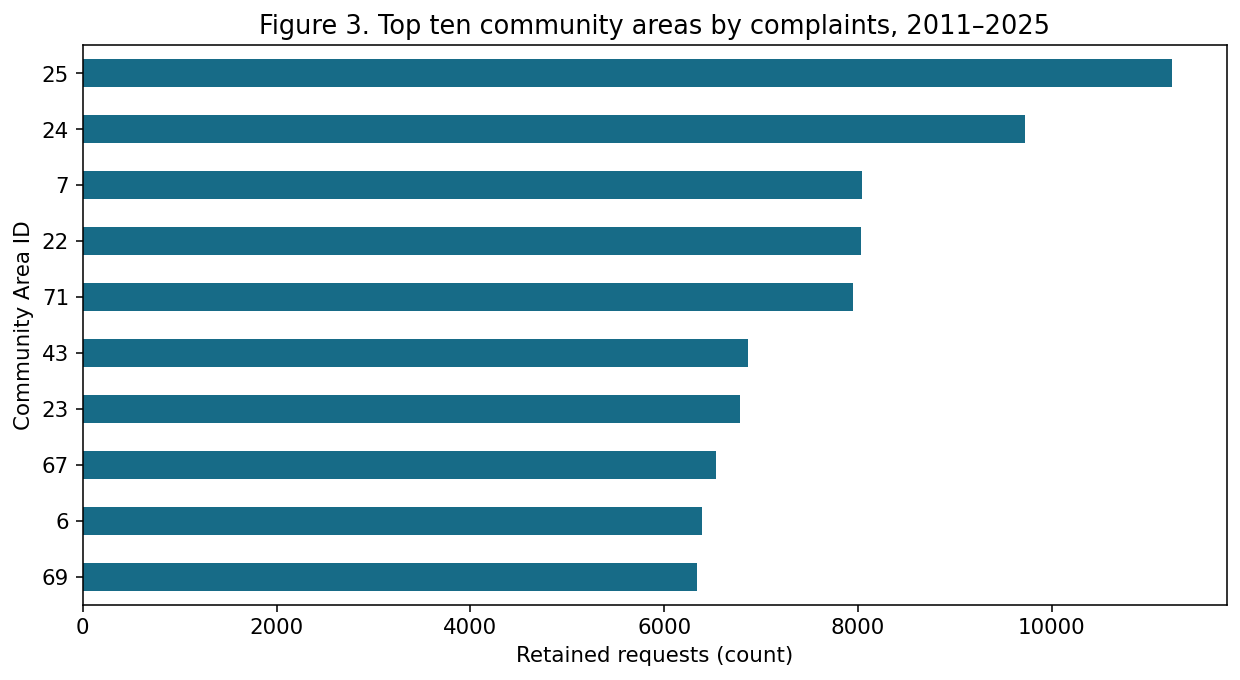

In [ ]:
area = pd.to_numeric(complaint_analysis['Community Area'], errors='coerce')
valid = area.between(1, 77) & area.mod(1).eq(0)
community_counts = area.loc[valid].astype(int).value_counts().head(10).rename('Complaints')
display(community_counts.rename_axis('Community Area').to_frame())
fig, ax = plt.subplots(figsize=(9, 5))
community_counts.sort_values().rename(index=str).plot.barh(ax=ax, color='#176B87')
ax.set(title='Figure 3. Top ten community areas by complaints, 2011–2025', xlabel='Retained requests (count)', ylabel='Community Area' + ' ID')
plt.tight_layout()
plt.show()
print(f'Excluded missing/invalid IDs: {(~valid).sum():,} of {len(complaint_analysis):,} requests.')
print(f'Leading community area: {community_counts.index[0]} with {community_counts.iloc[0]:,} requests.')

**Answer / takeaway:** Community area 25 leads with 11,241 retained requests during 2011–2025. These are raw complaint totals, not population-adjusted rates or confirmed sanitation violations. Community area IDs identify administrative geography; do not infer neighborhood names from IDs without a verified lookup.

### Q4. Which wards have the most recorded sanitation complaints?
**Decision:** Locate complaint workload using administrative areas as a complement to ZIP codes. Adapted from Jason's sanitation notebook, using the same deduplicated 2011–2025 requests as Figures 1–2. Valid IDs are whole numbers from 1 to 50; zero, missing, and out-of-range IDs are excluded from this ranking but retained in the main dataset.

Excluded missing/invalid IDs: 139 of 245,373 requests.
Leading ward: 6 with 10,298 requests.


,Complaints
Ward,
6,10298
32,9056
21,9048
7,8135
28,7960
17,7696
27,7400
9,7300
8,6648


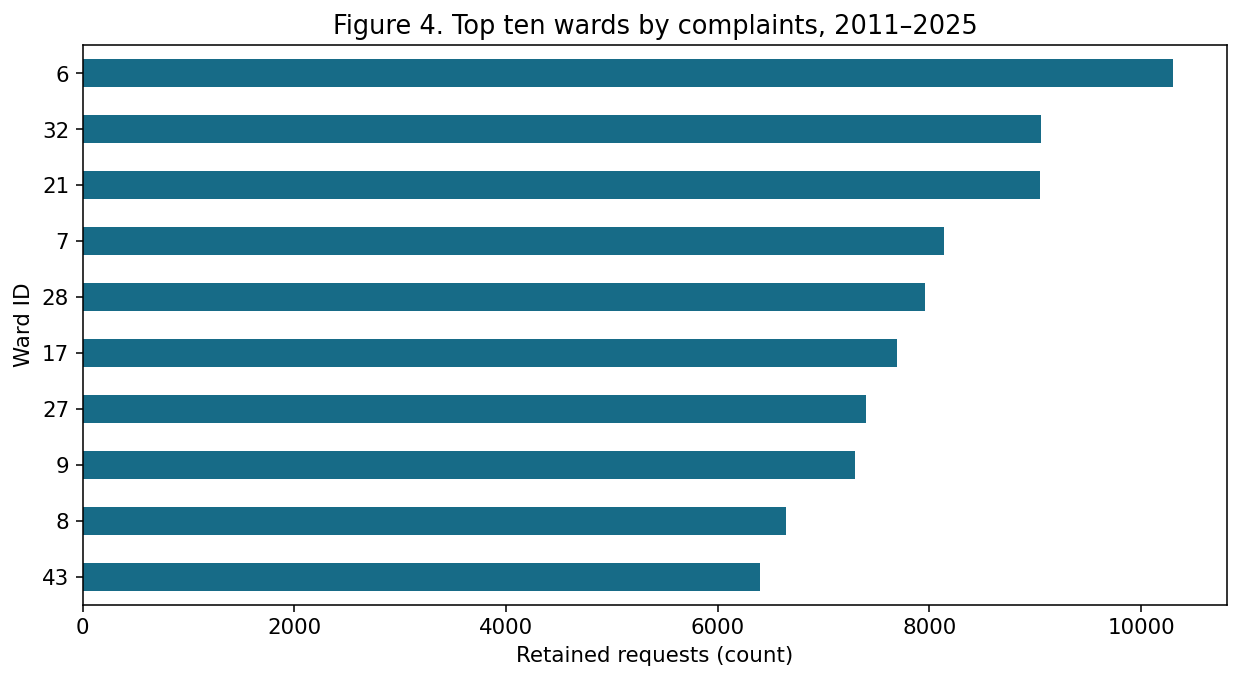

In [ ]:
area = pd.to_numeric(complaint_analysis['Ward'], errors='coerce')
valid = area.between(1, 50) & area.mod(1).eq(0)
ward_counts = area.loc[valid].astype(int).value_counts().head(10).rename('Complaints')
display(ward_counts.rename_axis('Ward').to_frame())
fig, ax = plt.subplots(figsize=(9, 5))
ward_counts.sort_values().rename(index=str).plot.barh(ax=ax, color='#176B87')
ax.set(title='Figure 4. Top ten wards by complaints, 2011–2025', xlabel='Retained requests (count)', ylabel='Ward' + ' ID')
plt.tight_layout()
plt.show()
print(f'Excluded missing/invalid IDs: {(~valid).sum():,} of {len(complaint_analysis):,} requests.')
print(f'Leading ward: {ward_counts.index[0]} with {ward_counts.iloc[0]:,} requests.')

**Answer / takeaway:** Ward 6 leads with 10,298 retained requests during 2011–2025. These are raw complaint totals, not population-adjusted rates or confirmed sanitation violations. Ward boundaries may change over time, so historical ward IDs should not be interpreted as a fixed current geography.

### Q5. Where are sanitation complaints located on a Chicago street map?
**Decision:** Put the geographic rankings in context by overlaying recorded complaint locations on Chicago streets. This adapts the OpenStreetMap overlay from `sanitation_analysis_jason_restored.ipynb`. Every retained 2011–2025 request with coordinates inside the map window is plotted; no random sample is used.

The approximate window includes O'Hare and is not an official city-boundary filter. Missing coordinates and points outside this window are excluded **only from this map**. Each red dot is a request, not a confirmed violation; overlapping points make this a coverage view rather than a reliable density or per-capita risk map.

The map requires `contextily` and its raster dependencies. If needed, install with `%pip install contextily`, then restart the kernel. The first run downloads OpenStreetMap tiles; later runs reuse `data/chicago_osm_z11.tif`. Keep that file with the data for offline reruns. Basemap attribution: © OpenStreetMap contributors.

Mapping 245,249 of 245,373 requests (99.95%).
Excluded from map only: 124 missing or out-of-window coordinates.
Projection: Web Mercator (EPSG:3857). Basemap: OpenStreetMap; zoom 11.


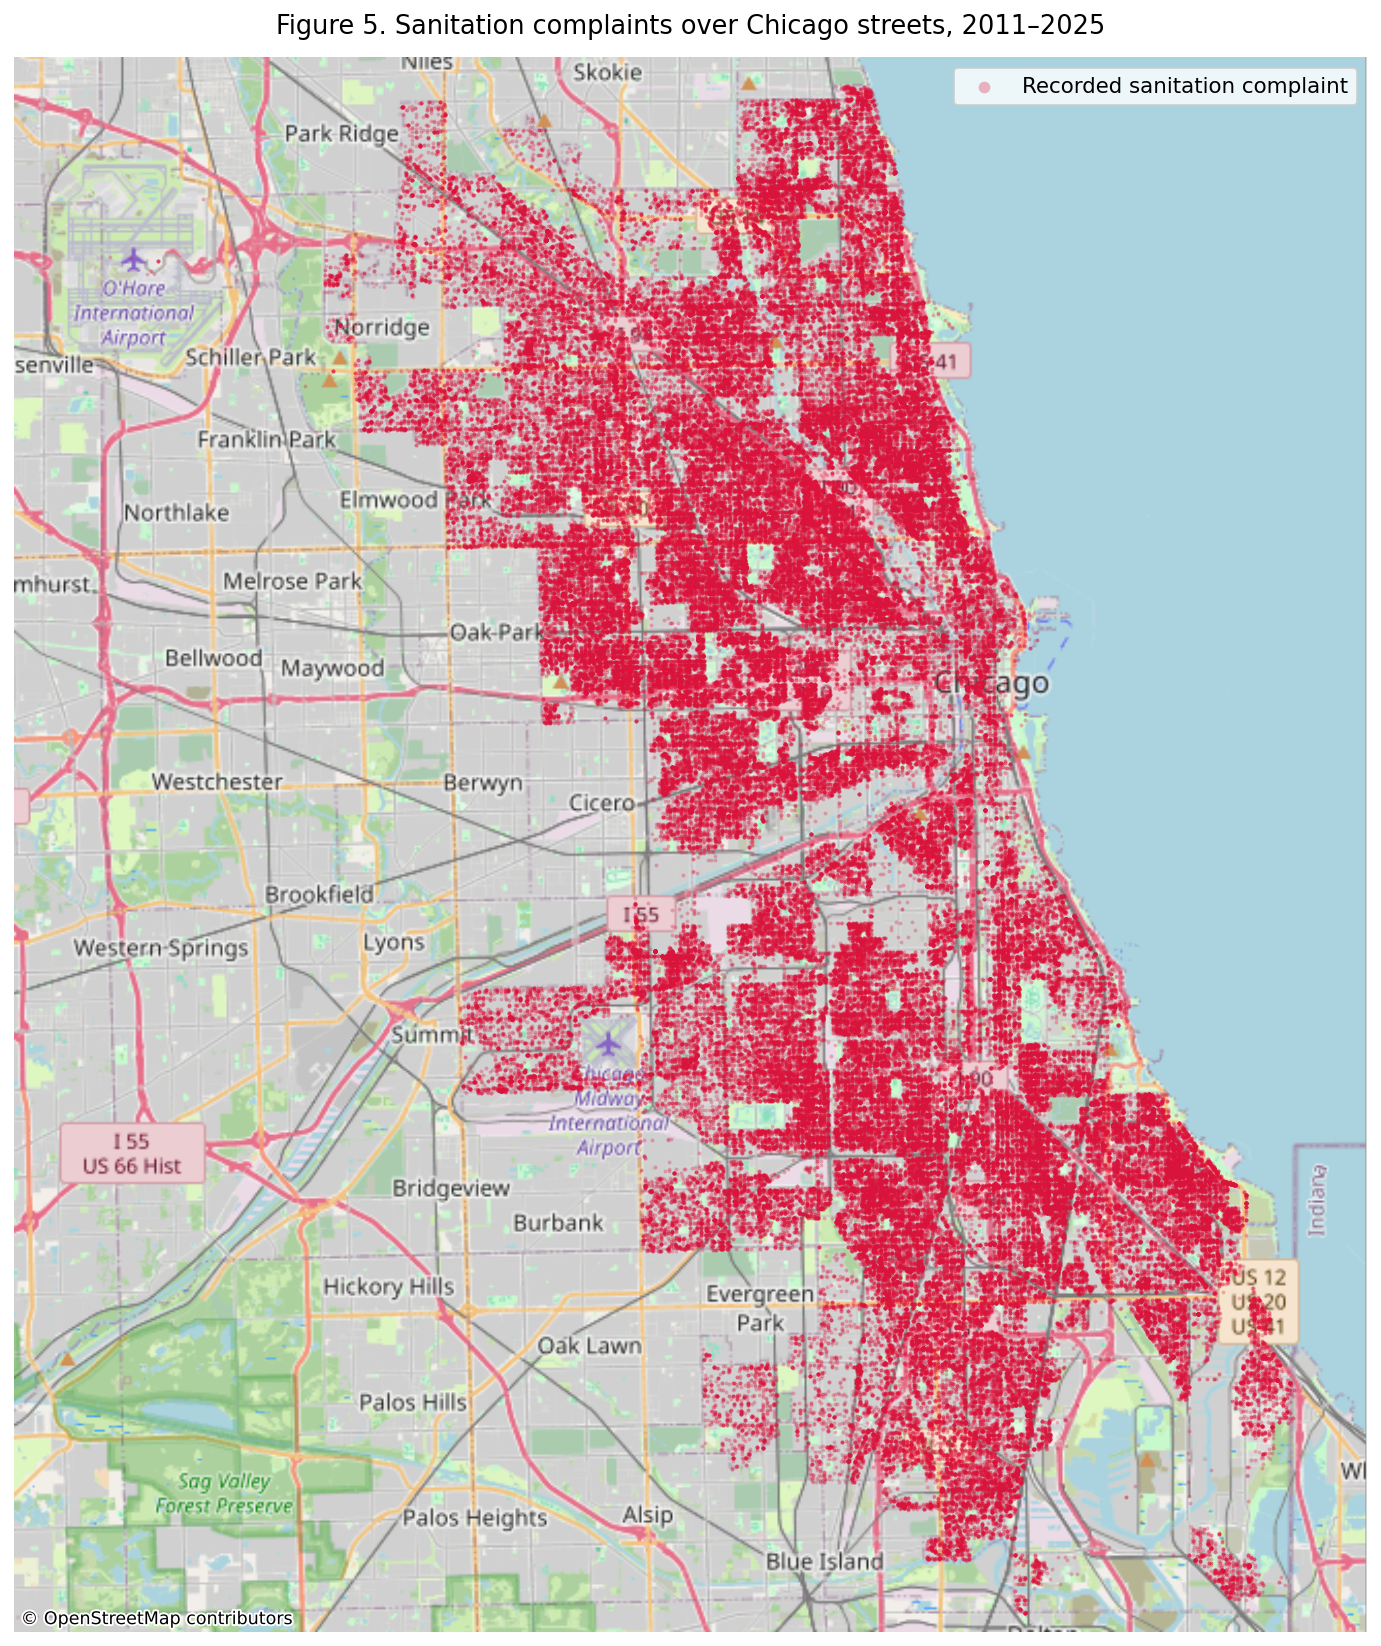

In [ ]:
import contextily as ctx

west, east, south, north = -87.95, -87.50, 41.64, 42.03
coordinates = complaint_analysis[['Latitude', 'Longitude']].apply(pd.to_numeric, errors='coerce')
in_map = coordinates['Latitude'].between(south, north) & coordinates['Longitude'].between(west, east)
location_df = coordinates.loc[in_map].copy()
print(f'Mapping {len(location_df):,} of {len(complaint_analysis):,} requests ({len(location_df)/len(complaint_analysis):.2%}).')
print(f'Excluded from map only: {(~in_map).sum():,} missing or out-of-window coordinates.')
if location_df.empty:
    raise ValueError('No valid coordinates available for the Chicago overlay map.')

def web_mercator(longitude, latitude):
    radius = 6378137.0
    return radius * np.deg2rad(longitude), radius * np.log(np.tan(np.pi/4 + np.deg2rad(latitude)/2))

x, y = web_mercator(location_df['Longitude'], location_df['Latitude'])
xmin, ymin = web_mercator(west, south)
xmax, ymax = web_mercator(east, north)
basemap_path = DATA_DIR / 'chicago_osm_z11.tif'
if not basemap_path.exists():
    ctx.bounds2raster(xmin, ymin, xmax, ymax, str(basemap_path), zoom=11,
                     source=ctx.providers.OpenStreetMap.Mapnik,
                     headers={'User-Agent': 'SanitationProjectNotebook/1.0 (https://github.com/idanm-commiting/Sanitation-Project)'},
                     n_connections=1, timeout=30)
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ctx.add_basemap(ax, source=str(basemap_path), attribution='© OpenStreetMap contributors', attribution_size=9)
ax.scatter(x, y, s=4, color='crimson', alpha=.3, linewidths=0,
           rasterized=True, zorder=2, label='Recorded sanitation complaint')
ax.set_aspect('equal')
ax.set_title('Figure 5. Sanitation complaints over Chicago streets, 2011–2025', pad=12)
ax.legend(loc='upper right', markerscale=3)
ax.set_axis_off()
plt.tight_layout()
plt.show()
print('Projection: Web Mercator (EPSG:3857). Basemap: OpenStreetMap; zoom 11.')

**Answer / takeaway:** The street-map overlay displays 245,249 requests (99.95% of the analytical sample), locating them within Chicago's road network and complements the ZIP, community-area, and ward rankings. Darker patches can reflect overlapping points, population, reporting patterns, and map scale; they do not establish which neighborhoods have the worst sanitation. The output above reports the mapped share and exclusions explicitly.

### Inspection outcomes: supporting tables
The following questions retain the food-inspection findings from the report. Tables provide the evidence while the five-chart allowance is devoted to the sanitation visualizations requested by the team.

### Q6. Do high-risk establishments have higher observed inspection failure rates?
**Decision:** Assess whether recorded risk classes help distinguish inspection outcomes. A failure rate is Fail / (Pass + Pass w/ Conditions + Fail); repeated inspections of a business remain separate events.

In [ ]:
def rate_table(frame, column):
    table = frame.groupby(column)['Failed'].agg(Inspections='size', Failures='sum')
    table['Fail rate %'] = table['Failures'].div(table['Inspections']).mul(100)
    return table
risk_rates = rate_table(analysis, 'Risk Clean').reindex(['High', 'Medium', 'Low', 'Unknown']).dropna()
display(risk_rates.round(2))

print(f'Overall: {analysis.Failed.sum():,} / {len(analysis):,} = {analysis.Failed.mean():.2%} failed.')

Overall: 23,843 / 103,614 = 23.01% failed.


,Inspections,Failures,Fail rate %
Risk Clean,,,
High,82424,18889,22.92
Medium,15880,3580,22.54
Low,5308,1374,25.89
Unknown,2,0,0.00


**Answer / takeaway:** No: High-risk inspections fail at 22.92%, compared with 22.54% for Medium and 25.89% for Low. This is an unadjusted inspection-level comparison: inspection type, repeat visits, calendar year, and facility mix may explain differences. Risk labels should be evaluated alongside these factors before changing inspection priorities. The Unknown category contains only two inspections and should not be interpreted as a stable failure-rate estimate.

### Q7. How do failure rates differ across common facility types?
**Decision:** Identify common business categories for compliance-outreach review. Select the ten largest groups by number of inspections, then compare failure percentages; this avoids presenting a rare category with one failure as the highest-risk business type.

In [ ]:
facility_rates = rate_table(analysis, 'Facility Clean').sort_values('Inspections', ascending=False).head(10).sort_values('Fail rate %', ascending=False)
display(facility_rates.round(2))

print('Groups selected by inspection volume, not by failure rate.')

Groups selected by inspection volume, not by failure rate.


,Inspections,Failures,Fail rate %
Facility Clean,,,
long term care,1069,287,26.85
school,7568,1941,25.65
bakery,1447,369,25.50
grocery store,10873,2743,25.23
mobile food preparer,584,134,22.95
daycare above and under 2 years,1709,392,22.94
restaurant,71154,16163,22.72
daycare (2 - 6 years),723,161,22.27
children's services facility,3884,694,17.87


**Answer / takeaway:** Among the ten most-inspected categories, **long term care** has the highest observed failure rate (26.85%, based on 1,069 inspections). This ranking supports reviewing outreach needs, but it is not adjusted for risk, inspection purpose, repeat visits, or residual labeling inconsistencies.

### Q8. Which violation codes are most frequently recorded in failed inspections?
**Decision:** Identify common recorded issues to investigate for training materials. Split pipe-separated findings and extract the leading numeric code. Count each code at most once per inspection, and retain code labels rather than inventing descriptions. Use 2019–2025 consistently with Q3–Q4; verify official code descriptions before translating these into training topics.

In [ ]:
failed = analysis.loc[analysis['Failed'].eq(1)].copy()
parts = failed[['Inspection ID', 'Violations']].dropna(subset=['Violations']).copy()
parts['Segment'] = parts['Violations'].astype('string').str.split('|', regex=False)
parts = parts.explode('Segment')
parts['Code'] = parts['Segment'].str.extract(r'^\s*(\d+)\s*\.', expand=False)
unparsed = parts['Code'].isna() & parts['Segment'].str.strip().ne('')
violation_counts = parts.dropna(subset=['Code']).drop_duplicates(['Inspection ID', 'Code'])['Code'].value_counts().head(10)
violation_table = violation_counts.rename('Failed inspections mentioning code').to_frame()
violation_table['% of all failed inspections'] = violation_counts.div(len(failed)).mul(100)
display(violation_table.round(2))

print(f'Denominator: {len(failed):,} failed inspections; missing violation text: {failed.Violations.isna().sum():,}.')
print(f'Nonempty segments without a parsed code: {unparsed.sum():,}. Multiple codes may appear in one inspection.')

Denominator: 23,843 failed inspections; missing violation text: 603.
Nonempty segments without a parsed code: 0. Multiple codes may appear in one inspection.


,Failed inspections mentioning code,% of all failed inspections
Code,,
55,14453,60.62
38,11048,46.34
10,9330,39.13
49,8281,34.73
47,7857,32.95
51,7248,30.40
56,5945,24.93
5,5348,22.43
3,5212,21.86


**Answer / takeaway:** Code 55 is the most frequently recorded code among failures, appearing in 14,453 failed inspections (60.62% of all failures in the window). These are co-recorded findings, not estimates of a code's effect on failure; percentages overlap because an inspection can mention several codes. A final-phase comparison with passed inspections and verified descriptions is needed before selecting specific interventions.

## 5. Conclusion
Our analysis found variation in Chicago sanitation complaint volume across years and locations, alongside differences in food-inspection failure rates by risk class and facility type. Among 245,373 retained complaints from 2011-2025, annual volume peaked at 19,970 in 2016 and reached its lowest level at 12,260 in 2019. The ten highest-volume ZIP codes accounted for 36.25% of complaints, with ZIP 60620 recording the largest total (11,282). Community area 25 and Ward 6 led their respective geographic rankings, with 11,241 and 10,298 requests. The street-map overlay placed 99.95% of the retained complaints within the map window, providing geographic context for these patterns.

Among 103,614 outcome-bearing inspections from 2019-2025, 23.01% failed. High-risk establishments did not have the highest observed failure rate: Low-risk inspections failed at 25.89%, compared with 22.92% for High-risk and 22.54% for Medium-risk inspections. Among the ten most-inspected facility categories, long term care had the highest failure rate at 26.85%, based on 1,069 inspections. Code 55 was the most frequently recorded violation code among failed inspections, appearing in 14,453 failures, or 60.62% of all failures in the period.

These findings describe recorded complaints and inspection outcomes in the supplied data. Complaint totals reflect reporting volume rather than population-adjusted sanitation risk, and the failure-rate comparisons are unadjusted for inspection purpose, repeat visits, year, and facility mix. Because complaints and inspections were analyzed separately, the results do not establish a relationship between complaint volume and inspection failure or identify the causes of the observed differences.


## 6. References
- City of Chicago, Department of Public Health. [Food Inspections](https://data.cityofchicago.org/Health-Human-Services/Food-Inspections/4ijn-s7e5). Primary source for inspection records; analysis uses the team's saved extracts.
- City of Chicago. [311 Service Requests — Sanitation Code Complaints — Historical](https://data.cityofchicago.org/Service-Requests/311-Service-Requests-Sanitation-Code-Complaints-Hi/me59-5fac). Historical source cited in the project draft.
- City of Chicago. [311 Service Requests](https://data.cityofchicago.org/Service-Requests/311-Service-Requests/v6vf-nfxy). Modern portal series to consult when verifying the combined extract's provenance; the notebook does not independently reconstruct that extract.
- City of Chicago. [Data Portal Terms of Use](https://www.chicago.gov/city/en/narr/foia/data_disclaimer.html). Consult the City's terms for reuse conditions; public availability is not an assertion of a specific open license.
- Team repository. [Sanitation-Project](https://github.com/idanm-commiting/Sanitation-Project). Five local ZIP inputs are enumerated and fingerprinted in Section 2.
- [OpenStreetMap contributors](https://www.openstreetmap.org/copyright). Street-map tiles used in Figure 5, © OpenStreetMap contributors.
- [contextily documentation](https://contextily.readthedocs.io/). Basemap download, caching, and display.
- Software documentation: [pandas](https://pandas.pydata.org/docs/), [NumPy](https://numpy.org/doc/), [Matplotlib](https://matplotlib.org/stable/). Runtime versions appear in Section 2.

## 7. Generative AI disclosure
OpenAI Codex was used to inspect the supplied documents and notebooks, expand the cleaning code, adapt Jason's five sanitation chart topics (including the OpenStreetMap overlay), retain food-inspection results as supporting tables, draft the executive summary and section interpretations, and organize this notebook against the rubric. The generated code was executed sequentially against the five local archives; numerical prose was populated from those execution results, and checks below verify key analytical assumptions and counts. The supplied Word draft also reports using Claude through a Microsoft Word add-in for report organization and drafting; that statement comes from the draft and has not been independently verified. The team should review the methodology, interpretations, source provenance, and this disclosure before submission; no team review is claimed here.

